   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.1/275.1 kB 5.9 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/mesa/mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Step   0 | Generated:   3 | Delivered:   0 | Queued:   3 | Reroutes:   0
Step   1 | Generated:   6 | Delivered:   0 | Queued:   6 | Reroutes:   4
Step   2 | Generated:   9 | Delivered:   2 | Queued:   7 | Reroutes:   7
Step   3 | Generated:  12 | Delivered:   2 | Queued:  10 | Reroutes:  11
Step   4 | Generated:  12 | Delivered:   4 | Queued:   8 | Reroutes:  18
Step   5 | Generated:  14 | Delivered:   5 | Queued:   9 | Reroutes:  21
Step   6 | Generated:  15 | Delivered:   6 | Queued:   9 | Reroutes:  22
Step   7 | Generated:  17 | Delivered:   9 | Queued:   8 | Reroutes:  26
Step   8 | Generated:  20 | Delivered:   9 | Queued:  11 | Reroutes:  27
Step   9 | Generated:  24 | Delivered:  12 | Queued:  12 | Reroutes:  37
Step  10 | Generated:  26 | Delivered:  12 | Queued:  14 | Reroutes:  37
Step  11 | Generated:  28 | Delivered:  15 | Queued:  13 | Reroutes:  42
Step  12 | Generated:  32 | Delivered:  16 | Queued:  16 | Reroutes:  52
Step  13 | Generated:  34 | Delivered:  16 | Queued

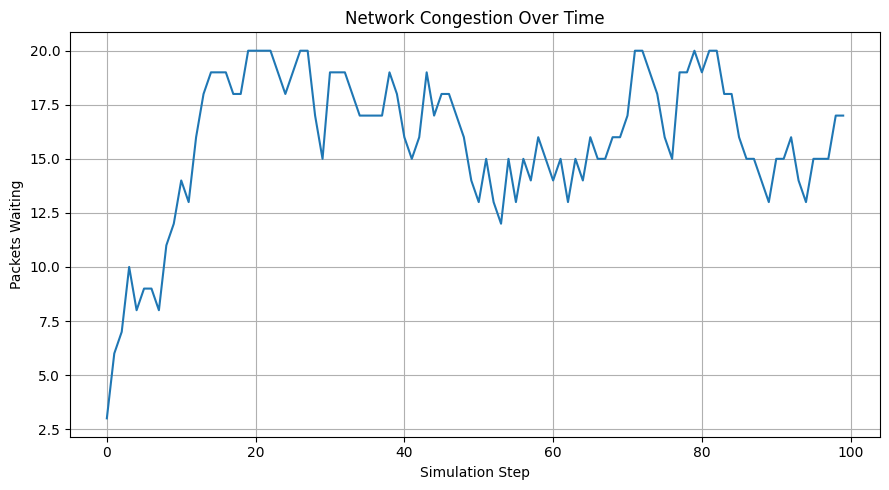

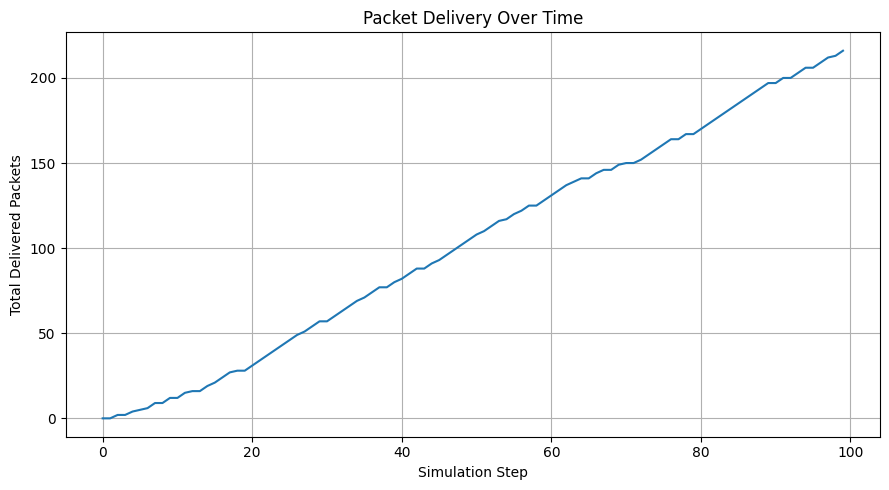

/tmp/ipykernel_534/3642617484.py:351: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


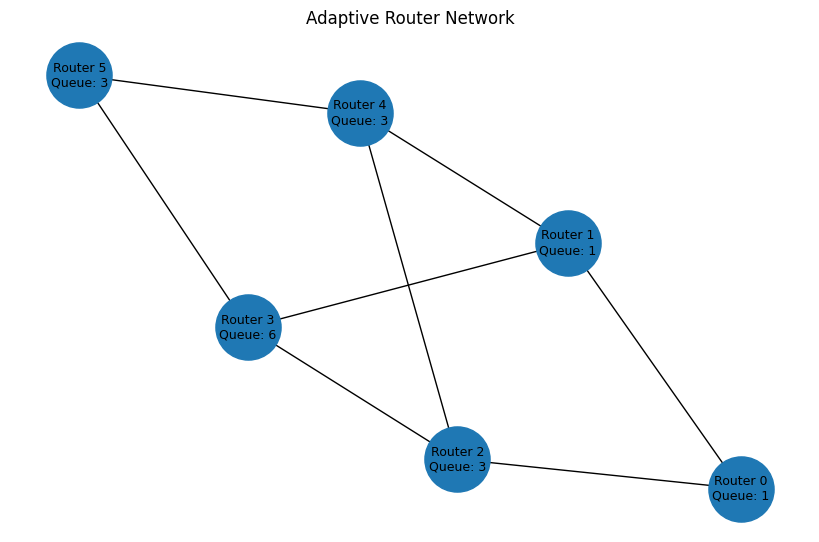

In [3]:
!pip install mesa

import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import networkx as nx
from mesa import Agent, Model


RANDOM_SEED = 42
SIMULATION_STEPS = 100
ROUTER_CAPACITY = 3
CONGESTION_THRESHOLD = 5

random.seed(RANDOM_SEED)


@dataclass
class Packet:
    packet_id: int
    source: int
    destination: int
    creation_step: int
    current_router: int
    hops: int = 0


class RouterAgent(Agent):
    """Router that adaptively forwards packets."""

    def __init__(self, model, router_id):
        super().__init__(model)

        self.router_id = router_id
        self.packet_queue = []
        self.processed_packets = 0
        self.rerouted_packets = 0

    @property
    def congestion(self):
        return len(self.packet_queue)

    def receive_packet(self, packet):
        self.packet_queue.append(packet)

    def choose_next_router(self, packet):
        """
        Select a neighboring router.

        The score considers:
        1. Neighbor queue length.
        2. Shortest remaining path to the destination.
        """

        graph = self.model.network
        neighbors = list(graph.neighbors(self.router_id))

        if not neighbors:
            return None

        possible_routes = []

        for neighbor_id in neighbors:
            try:
                remaining_distance = nx.shortest_path_length(
                    graph,
                    source=neighbor_id,
                    target=packet.destination
                )
            except nx.NetworkXNoPath:
                continue

            neighbor = self.model.routers[neighbor_id]
            queue_length = neighbor.congestion

            # Congestion is given more weight than path length.
            routing_score = remaining_distance + 2 * queue_length

            possible_routes.append(
                (routing_score, queue_length, neighbor_id)
            )

        if not possible_routes:
            return None

        possible_routes.sort()
        selected_neighbor = possible_routes[0][2]

        # Determine the normal shortest-path choice.
        shortest_path = nx.shortest_path(
            graph,
            source=self.router_id,
            target=packet.destination
        )

        normal_neighbor = (
            shortest_path[1]
            if len(shortest_path) > 1
            else packet.destination
        )

        # Record when congestion causes a different route.
        if selected_neighbor != normal_neighbor:
            self.rerouted_packets += 1
            self.model.total_reroutes += 1

        return selected_neighbor

    def step(self):
        packets_to_process = min(
            ROUTER_CAPACITY,
            len(self.packet_queue)
        )

        for _ in range(packets_to_process):
            packet = self.packet_queue.pop(0)

            if self.router_id == packet.destination:
                latency = self.model.current_step - packet.creation_step

                self.model.delivered_packets += 1
                self.model.packet_latencies.append(latency)
                self.processed_packets += 1
                continue

            next_router_id = self.choose_next_router(packet)

            if next_router_id is not None:
                packet.current_router = next_router_id
                packet.hops += 1

                self.model.pending_transfers.append(
                    (next_router_id, packet)
                )

                self.processed_packets += 1


class UserAgent(Agent):
    """User that creates network packets."""

    def __init__(
        self,
        model,
        user_id,
        connected_router,
        destination_router,
        generation_probability=0.6
    ):
        super().__init__(model)

        self.user_id = user_id
        self.connected_router = connected_router
        self.destination_router = destination_router
        self.generation_probability = generation_probability

    def step(self):
        if random.random() < self.generation_probability:
            packet = Packet(
                packet_id=self.model.next_packet_id,
                source=self.connected_router,
                destination=self.destination_router,
                creation_step=self.model.current_step,
                current_router=self.connected_router
            )

            self.model.next_packet_id += 1
            self.model.generated_packets += 1

            self.model.routers[
                self.connected_router
            ].receive_packet(packet)


class AdaptiveNetworkModel(Model):
    """Mesa model for adaptive network routing."""

    def __init__(self):
        super().__init__(seed=RANDOM_SEED)

        self.current_step = 0
        self.next_packet_id = 1

        self.generated_packets = 0
        self.delivered_packets = 0
        self.total_reroutes = 0

        self.packet_latencies = []
        self.congestion_history = []
        self.delivery_history = []
        self.reroute_history = []

        self.pending_transfers = []

        self.network = nx.Graph()

        # Multiple paths allow adaptive routing.
        connections = [
            (0, 1),
            (0, 2),
            (1, 3),
            (2, 3),
            (1, 4),
            (2, 4),
            (3, 5),
            (4, 5)
        ]

        self.network.add_edges_from(connections)

        self.routers = {
            router_id: RouterAgent(self, router_id)
            for router_id in self.network.nodes
        }

        self.users = [
            UserAgent(self, 0, connected_router=0, destination_router=5),
            UserAgent(self, 1, connected_router=0, destination_router=5),
            UserAgent(self, 2, connected_router=1, destination_router=5),
            UserAgent(self, 3, connected_router=2, destination_router=5)
        ]

    def calculate_total_congestion(self):
        return sum(
            router.congestion
            for router in self.routers.values()
        )

    def step(self):
        # Users generate packets.
        users = list(self.users)
        random.shuffle(users)

        for user in users:
            user.step()

        # Routers make forwarding decisions.
        routers = list(self.routers.values())
        random.shuffle(routers)

        self.pending_transfers = []

        for router in routers:
            router.step()

        # Apply transfers after all routers complete their decisions.
        # This prevents a packet from crossing multiple routers in one step.
        for router_id, packet in self.pending_transfers:
            self.routers[router_id].receive_packet(packet)

        total_congestion = self.calculate_total_congestion()

        self.congestion_history.append(total_congestion)
        self.delivery_history.append(self.delivered_packets)
        self.reroute_history.append(self.total_reroutes)

        print(
            f"Step {self.current_step:3d} | "
            f"Generated: {self.generated_packets:3d} | "
            f"Delivered: {self.delivered_packets:3d} | "
            f"Queued: {total_congestion:3d} | "
            f"Reroutes: {self.total_reroutes:3d}"
        )

        self.current_step += 1


model = AdaptiveNetworkModel()

for _ in range(SIMULATION_STEPS):
    model.step()


print("\n" + "=" * 55)
print("AGENT-BASED MODEL RESULTS")
print("=" * 55)

average_latency = (
    sum(model.packet_latencies) / len(model.packet_latencies)
    if model.packet_latencies
    else 0
)

throughput = model.delivered_packets / SIMULATION_STEPS

print(f"Packets generated: {model.generated_packets}")
print(f"Packets delivered: {model.delivered_packets}")
print(f"Packets queued:    {model.calculate_total_congestion()}")
print(f"Adaptive reroutes: {model.total_reroutes}")
print(f"Average latency:   {average_latency:.2f} steps")
print(f"Throughput:        {throughput:.2f} packets/step")


# Plot congestion over time.
plt.figure(figsize=(9, 5))
plt.plot(
    range(SIMULATION_STEPS),
    model.congestion_history
)
plt.xlabel("Simulation Step")
plt.ylabel("Packets Waiting")
plt.title("Network Congestion Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot delivered packets over time.
plt.figure(figsize=(9, 5))
plt.plot(
    range(SIMULATION_STEPS),
    model.delivery_history
)
plt.xlabel("Simulation Step")
plt.ylabel("Total Delivered Packets")
plt.title("Packet Delivery Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()


# Display the network.
plt.figure(figsize=(8, 5))

positions = nx.spring_layout(
    model.network,
    seed=RANDOM_SEED
)

router_labels = {
    node: f"Router {node}\nQueue: {model.routers[node].congestion}"
    for node in model.network.nodes
}

nx.draw(
    model.network,
    positions,
    with_labels=False,
    node_size=2200
)

nx.draw_networkx_labels(
    model.network,
    positions,
    labels=router_labels,
    font_size=9
)

plt.title("Adaptive Router Network")
plt.tight_layout()
plt.show()